# preparing dataset

In [66]:
import pandas as pd 
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

from warnings import filterwarnings

filterwarnings(action='ignore')

In [67]:
# path
DATA = Path("./data")
RAW_DATA = DATA / "raw" / "iris.csv"

In [68]:
df = pd.read_csv(RAW_DATA)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [69]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [70]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

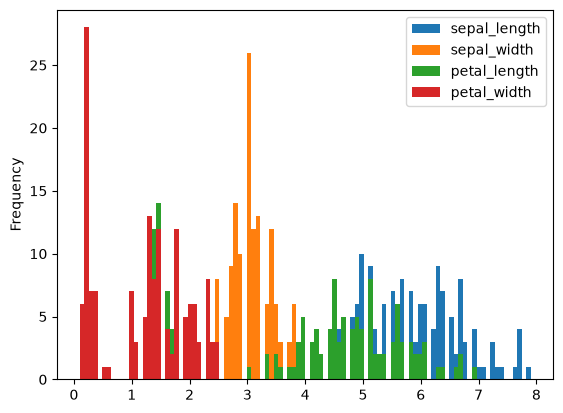

In [71]:
df.plot(kind='hist', bins=100)
plt.show()

In [72]:
# outliers 
def remove_outliers(df):
    df = df.copy()

    Q1 = df.select_dtypes(include=[np.number]).quantile(0.25)
    Q3 = df.select_dtypes(include=[np.number]).quantile(0.75)


    IQR = Q3 - Q1

    upr_bnd = Q3 + IQR * 1.5
    lwr_bnd = Q1 - IQR * 1.5

    outliers = ((df.select_dtypes(include=[np.number]) > upr_bnd) | (df.select_dtypes(include=[np.number]) < lwr_bnd))
    df.drop(index=(outliers[outliers.any(axis=1)].index), inplace=True)

    return df

# droping null values
df = remove_outliers(df)
df.dropna(inplace=True)

In [73]:
# preparing for training
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = df.select_dtypes(include=[np.number]).columns.to_list()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
])

le = LabelEncoder()


X = preprocessor.fit_transform(df)
y = le.fit_transform(df['species'])


### Training

In [74]:
# training base model
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.dummy import DummyClassifier

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_clf = DummyClassifier(strategy='prior')
dummy_clf.fit(train_X, train_y)

y_pred = dummy_clf.predict(test_X)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [77]:
# evalution
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate(model, test_X, test_y):
    y_pred = model.predict(test_X)

    accuracy = accuracy_score(test_y, y_pred)
    cnfn_mat = confusion_matrix(test_y, y_pred)

    print("Accuracy: ", accuracy)
    print()
    print("Classification report:\n======================")
    print()
    print(classification_report(test_y, y_pred))


evaluate(dummy_clf, test_X, test_y)

Accuracy:  0.26666666666666666

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.27      1.00      0.42         8
           2       0.00      0.00      0.00        10

    accuracy                           0.27        30
   macro avg       0.09      0.33      0.14        30
weighted avg       0.07      0.27      0.11        30



In [ ]:
# logistic regression model
from sklearn.linear_model import LogisticRegression

lg_clf = LogisticRegression()
lg_clf.fit(train_X, train_y)

evaluate(lg_clf, test_X, test_y)

Accuracy:  0.9333333333333333

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30

